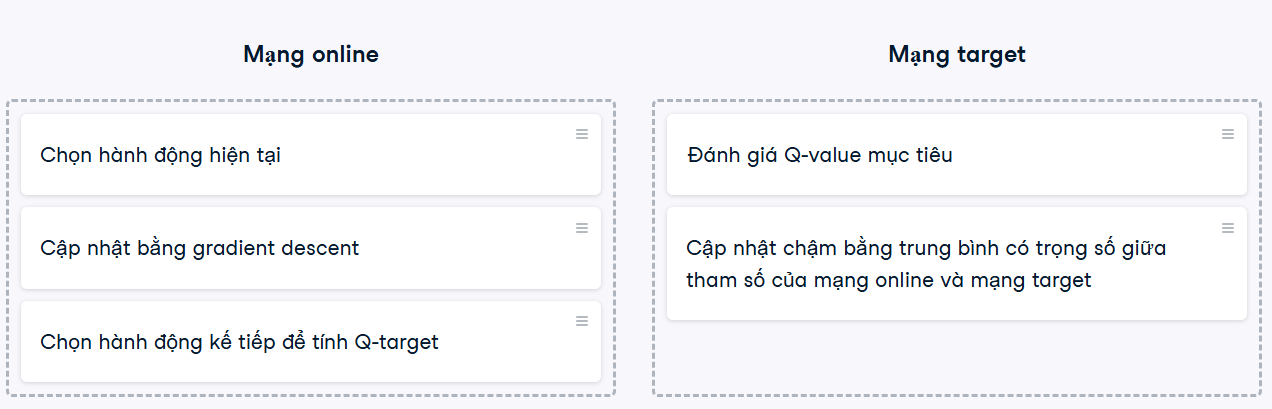

Huấn luyện Double DQN
Bây giờ bạn sẽ chỉnh sửa mã DQN của mình để triển khai Double DQN.

Double DQN chỉ cần điều chỉnh rất nhỏ so với thuật toán DQN, nhưng giúp giải quyết đáng kể vấn đề ước lượng quá cao Q-value và thường cho hiệu năng tốt hơn DQN.

Hướng dẫn
100 XP
Tính các hành động tiếp theo phục vụ phép tính Q-target bằng online_network(), đảm bảo chọn đúng hành động và đúng hình dạng dữ liệu.
Ước lượng các Q-value ứng với các hành động này bằng target_network(), và một lần nữa, đảm bảo lấy đúng giá trị và đúng hình dạng.

In [ ]:
for episode in range(10):
    state, info = env.reset()
    done = False
    step = 0
    episode_reward = 0
    while not done:
        step += 1
        total_steps += 1
        q_values = online_network(state)
        action = select_action(q_values, total_steps, start=.9, end=.05, decay=1000)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        replay_buffer.push(state, action, reward, next_state, done)        
        if len(replay_buffer) >= batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(64)
            q_values = online_network(states).gather(1, actions).squeeze(1)
            with torch.no_grad():
                # Obtain next actions for Q-target calculation
                next_actions = ____.____.____
                # Estimate next Q-values from these actions
                next_q_values = ____.____.____
                target_q_values = rewards + gamma * next_q_values * (1-dones)
            loss = nn.MSELoss()(q_values, target_q_values)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            update_target_network(target_network, online_network, tau=.005)
        state = next_state
        episode_reward += reward    
    describe_episode(episode, reward, episode_reward, step)

In [ ]:
"""
Truyền next_states vào online_network() để lấy hành động tiếp theo; dùng .argmax(1) để chọn hành động, rồi .unsqueeze(1) để có đúng hình dạng (batch_size, 1).
Cung cấp các hành động này làm chỉ số cho target_network, sử dụng phương thức .gather(1, ...) để lấy các Q-value tiếp theo;
 sau đó dùng .squeeze() để chuyển từ dạng (batch_size, 1) về (batch_size).


 
for episode in range(10):
    state, info = env.reset()
    done = False
    step = 0
    episode_reward = 0
    while not done:
        step += 1
        total_steps += 1
        q_values = online_network(state)
        action = select_action(q_values, total_steps, start=.9, end=.05, decay=1000)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        replay_buffer.push(state, action, reward, next_state, done)        
        if len(replay_buffer) >= batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(64)
            q_values = online_network(states).gather(1, actions).squeeze(1)
            with torch.no_grad():
                # Obtain next actions for Q-target calculation
                next_actions = online_network(next_states).argmax(1).unsqueeze(1)
                # Estimate next Q-values from these actions
                next_q_values = target_network(next_states).gather(1, next_actions).squeeze(1)
                target_q_values = rewards + gamma * next_q_values * (1-dones)
            loss = nn.MSELoss()(q_values, target_q_values)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            update_target_network(target_network, online_network, tau=.005)
        state = next_state
        episode_reward += reward    
    describe_episode(episode, reward, episode_reward, step)
     
 """